In [1]:
# قم بتحميل ملف بيانات COVID-19 باستخدام Pandas 
import pandas as pd 
df = pd.read_csv('covid_19.csv') 

In [3]:
# اعرض معلومات البيانات باستخدام info()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61900 entries, 0 to 61899
Data columns (total 12 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   dateRep                                                     61900 non-null  object 
 1   day                                                         61900 non-null  int64  
 2   month                                                       61900 non-null  int64  
 3   year                                                        61900 non-null  int64  
 4   cases                                                       61900 non-null  int64  
 5   deaths                                                      61900 non-null  int64  
 6   countriesAndTerritories                                     61900 non-null  object 
 7   geoId                                                       61625 non-null  object 
 

In [5]:
# اعرض أول 5 سجلات
df.head(5)

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000
0,14/12/2020,14,12,2020,746,6,Afghanistan,AF,AFG,38041757.0,Asia,9.013779
1,13/12/2020,13,12,2020,298,9,Afghanistan,AF,AFG,38041757.0,Asia,7.052776
2,12/12/2020,12,12,2020,113,11,Afghanistan,AF,AFG,38041757.0,Asia,6.868768
3,11/12/2020,11,12,2020,63,10,Afghanistan,AF,AFG,38041757.0,Asia,7.134266
4,10/12/2020,10,12,2020,202,16,Afghanistan,AF,AFG,38041757.0,Asia,6.968658


In [7]:
# حدد عدد الصفوف والأعمدة
df.shape

(61900, 12)

In [9]:
# حدد أسماء الأعمدة وأنواع البيانات
print( "Name Of Columns : \n " , df.columns,"\n")
print("Data Type Of Columns : \n", df.dtypes )

Name Of Columns : 
  Index(['dateRep', 'day', 'month', 'year', 'cases', 'deaths',
       'countriesAndTerritories', 'geoId', 'countryterritoryCode',
       'popData2019', 'continentExp',
       'Cumulative_number_for_14_days_of_COVID-19_cases_per_100000'],
      dtype='object') 

Data Type Of Columns : 
 dateRep                                                        object
day                                                             int64
month                                                           int64
year                                                            int64
cases                                                           int64
deaths                                                          int64
countriesAndTerritories                                        object
geoId                                                          object
countryterritoryCode                                           object
popData2019                                                   fl

المرحلة 2: تنظيف البيانات المهمة 

In [12]:
 # احذف الأعمدة التي لا تحتاج إليها في التحليل

df = df.drop(columns=[
    "dateRep",
    "geoId",
    "countryterritoryCode",
    "continentExp",
    "Cumulative_number_for_14_days_of_COVID-19_cases_per_100000"
])

print(df.head())

   day  month  year  cases  deaths countriesAndTerritories  popData2019
0   14     12  2020    746       6             Afghanistan   38041757.0
1   13     12  2020    298       9             Afghanistan   38041757.0
2   12     12  2020    113      11             Afghanistan   38041757.0
3   11     12  2020     63      10             Afghanistan   38041757.0
4   10     12  2020    202      16             Afghanistan   38041757.0


In [14]:
# حفظ البيانات بعد التنظيف في ملف جديد
df.to_csv("covid_19_cleaned.csv", index=False)
print(df.head())

   day  month  year  cases  deaths countriesAndTerritories  popData2019
0   14     12  2020    746       6             Afghanistan   38041757.0
1   13     12  2020    298       9             Afghanistan   38041757.0
2   12     12  2020    113      11             Afghanistan   38041757.0
3   11     12  2020     63      10             Afghanistan   38041757.0
4   10     12  2020    202      16             Afghanistan   38041757.0


In [16]:
 # تحقق من القيم المفقودة
 # التحقق باستخدام isnull()
print(df.isnull().sum())

day                          0
month                        0
year                         0
cases                        0
deaths                       0
countriesAndTerritories      0
popData2019                123
dtype: int64


In [18]:
# التحقق باستخدام isna()
print(df.isna().sum())

day                          0
month                        0
year                         0
cases                        0
deaths                       0
countriesAndTerritories      0
popData2019                123
dtype: int64


In [20]:
# اما نلجأ الى معالجة جميع الاعمدة الرقمية مره واحده 
df.fillna(df.select_dtypes(include="number").mean(), inplace=True)

In [22]:
print(df.isnull().sum())

day                        0
month                      0
year                       0
cases                      0
deaths                     0
countriesAndTerritories    0
popData2019                0
dtype: int64


In [24]:
# او معالجة البيانات المفقودة رقميأ بتتحديد العمود المطلوب
df["popData2019"] = df["popData2019"].fillna(df["popData2019"].mean())

In [26]:
print(df.isnull().sum())

day                        0
month                      0
year                       0
cases                      0
deaths                     0
countriesAndTerritories    0
popData2019                0
dtype: int64


تجهيز البيانات المهمة : 4 

In [29]:
# حوّل بيانات السكان من القيمة الأصلية إلى ملايين السكان، ثم قرّبها إلى منزلتين عشريتين
df["popData2019"] = (df["popData2019"] / 1_000_000).round(2)
print(df["popData2019"].head(5))
print(df["popData2019"].tail(5))

0    38.04
1    38.04
2    38.04
3    38.04
4    38.04
Name: popData2019, dtype: float64
61895    14.65
61896    14.65
61897    14.65
61898    14.65
61899    14.65
Name: popData2019, dtype: float64


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61900 entries, 0 to 61899
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   day                      61900 non-null  int64  
 1   month                    61900 non-null  int64  
 2   year                     61900 non-null  int64  
 3   cases                    61900 non-null  int64  
 4   deaths                   61900 non-null  int64  
 5   countriesAndTerritories  61900 non-null  object 
 6   popData2019              61900 non-null  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 3.3+ MB


تم معالجة القيم المفقودة

In [33]:
# المهمة 5: غيّر أسماء الأعمدة لتكون أبسط
df.rename(columns={
    "countriesAndTerritories": "Countries",
    "popData2019": "Population"
}, inplace=True)

In [36]:
df.head()

,day,month,year,cases,deaths,Countries,Population
0,14,12,2020,746,6,Afghanistan,38.04
1,13,12,2020,298,9,Afghanistan,38.04
2,12,12,2020,113,11,Afghanistan,38.04
3,11,12,2020,63,10,Afghanistan,38.04
4,10,12,2020,202,16,Afghanistan,38.04


In [38]:
# OR
df = df.rename(columns={
    "countriesAndTerritories": "Countries",
    "popData2019": "Population"})

In [40]:
df.head()

,day,month,year,cases,deaths,Countries,Population
0,14,12,2020,746,6,Afghanistan,38.04
1,13,12,2020,298,9,Afghanistan,38.04
2,12,12,2020,113,11,Afghanistan,38.04
3,11,12,2020,63,10,Afghanistan,38.04
4,10,12,2020,202,16,Afghanistan,38.04


In [42]:
# المرحلة 4: الاستكشاف الإحصائي المهمة 
df.describe()

,day,month,year,cases,deaths,Population
count,61900.000000,61900.000000,61900.000000,61900.000000,61900.000000,61900.000000
mean,15.628934,7.067157,2019.998918,1155.147237,26.055460,40.987476
std,8.841582,2.954776,0.032882,6779.224479,131.227055,152.977177
min,1.000000,1.000000,2019.000000,-8261.000000,-1918.000000,0.000000
25%,8.000000,5.000000,2020.000000,0.000000,0.000000,1.320000
50%,15.000000,7.000000,2020.000000,15.000000,0.000000,7.810000
75%,23.000000,10.000000,2020.000000,273.000000,4.000000,28.610000
max,31.000000,12.000000,2020.000000,234633.000000,4928.000000,1433.780000


In [46]:
# السجل الذي يحتوي على أعلى عدد وفيات
MaxDeaths = df["deaths"].max()
print("MaxDeathes : ", MaxDeaths)
print("Recored Of MaxDeaths :\n ",df[df["deaths"] == MaxDeaths])

MaxDeathes :  4928
Recored Of MaxDeaths :
         day  month  year  cases  deaths                 Countries  Population
59243   16      4  2020  30148    4928  United_States_of_America      329.06


In [48]:
# السجل الذي يحتوي على أعلى عدد إصابات
MaxCases = df["cases"].max()
print("Max Cases : ", MaxCases)
print(" Recored Of MaxCases:\n ",df[df["cases"] == MaxCases])

Max Cases :  234633
 Recored Of MaxCases:
         day  month  year   cases  deaths                 Countries  Population
59003   12     12  2020  234633    3343  United_States_of_America      329.06


In [50]:
negative_cases = df[df["cases"] < 0]
print(negative_cases.count(),"\n")
print("NegativeCases = \n", negative_cases)

day           18
month         18
year          18
cases         18
deaths        18
Countries     18
Population    18
dtype: int64 

NegativeCases = 
        day  month  year  cases  deaths  \
6311    20      5  2020   -209       0   
10935   10      3  2020     -9       1   
16906    7      9  2020  -8261    3800   
17024   12      5  2020    -50      18   
17027    9      5  2020  -1480      50   
17029    7      5  2020  -2461      49   
20558    3      6  2020   -766     107   
29276   20      6  2020   -148      47   
30170   11      9  2020     -6       0   
30491   22      7  2020   -110       0   
34222   29      4  2020   -105       3   
34442   28      8  2020  -1385       0   
45901    3      5  2020   -161      16   
48566   11      5  2020     -9       0   
52925   25      5  2020   -372   -1918   
52961   19      4  2020   -713     410   
57685    2      6  2020     -1       0   
57697   21      5  2020   -115       0   

                                        Countries

In [52]:
# معالجة القيم السالبة في cases و deaths

df.loc[df["cases"] < 0, "cases"] = 0
df.loc[df["deaths"] < 0, "deaths"] = 0

# التحقق من عدم وجود قيم سالبة
print("NegativeCases :")
print(df[df["cases"] < 0])

print("NegativeDeaths :")
print(df[df["deaths"] < 0])

NegativeCases :
Empty DataFrame
Columns: [day, month, year, cases, deaths, Countries, Population]
Index: []
NegativeDeaths :
Empty DataFrame
Columns: [day, month, year, cases, deaths, Countries, Population]
Index: []


In [54]:
# حساب متوسط الإصابات اليومية عالميًا
average_cases = df["cases"].mean()

# حساب متوسط الوفيات اليومية عالميًا
average_deaths = df["deaths"].mean()

print("Average daily cases worldwide:", round(average_cases, 2))
print("Average daily deaths worldwide:", round(average_deaths, 2))

Average daily cases worldwide: 1155.41
Average daily deaths worldwide: 26.09


In [56]:
#عدد الأيام التي تغطيها البيانات
ddf = pd.read_csv("covid_19.csv")

number_of_days = ddf["dateRep"].nunique()
print("Number of days covered by the data:", number_of_days)

Number of days covered by the data: 350


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61900 entries, 0 to 61899
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   day         61900 non-null  int64  
 1   month       61900 non-null  int64  
 2   year        61900 non-null  int64  
 3   cases       61900 non-null  int64  
 4   deaths      61900 non-null  int64  
 5   Countries   61900 non-null  object 
 6   Population  61900 non-null  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 3.3+ MB


In [81]:
# المرحلة 7: التحليل حسب الدولة المهمة

# حساب متوسط الإصابات والوفيات لكل دولة
country_average = df.groupby("Countries")[["cases", "deaths"]].mean()

# أعلى 5 دول من حيث متوسط الوفيات
top_5_deaths = country_average["deaths"].sort_values(ascending=False).head(5)

# أعلى 5 دول من حيث متوسط الإصابات
top_5_cases = country_average["cases"].sort_values(ascending=False).head(5)

print("Top 5 countries by average deaths:")
print(top_5_deaths)

print("\nTop 5 countries by average cases:")
print(top_5_cases)

Top 5 countries by average deaths:
Countries
United_States_of_America    854.791429
Brazil                      518.291429
India                       410.759312
Mexico                      325.580000
Italy                       184.431429
Name: deaths, dtype: float64

Top 5 countries by average cases:
Countries
United_States_of_America    46447.868571
India                       28321.203438
Brazil                      19719.862857
Russia                       7582.651429
France                       6793.194286
Name: cases, dtype: float64


In [83]:
#  11: احسب إجمالي:
# الإصابات لكل شهر.
# الوفيات لكل شهر.
# ثم اعرض النتائج في جدول

ddf = pd.read_csv("covid_19.csv")
# تحويل عمود التاريخ إلى صيغة تاريخ
ddf["dateRep"] = pd.to_datetime(ddf["dateRep"] ,dayfirst=True)

# استخراج الشهر
df["Month"] = ddf["dateRep"].dt.to_period("M")

# حساب إجمالي الإصابات والوفيات لكل شهر
monthly_data = df.groupby("Month")[["cases", "deaths"]].sum()

# عرض النتائج في جدول
print(monthly_data)

            cases  deaths
Month                    
2019-12        27       0
2020-01      9799     213
2020-02     75422    2708
2020-03    723747   35814
2020-04   2340412  189180
2020-05   2896853  142060
2020-06   4250440  134100
2020-07   7067634  166199
2020-08   7965221  179075
2020-09   8464515  162169
2020-10  11949041  181059
2020-11  17134026  271086
2020-12   8642838  151585


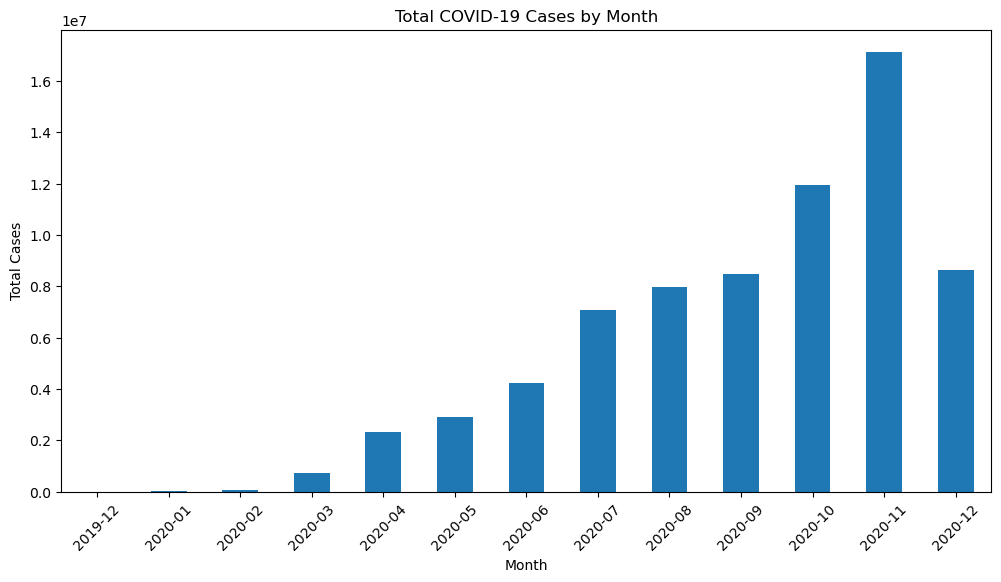

In [86]:
import matplotlib.pyplot as plt

# رسم إجمالي الإصابات حسب الشهر
monthly_data["cases"].plot(
    kind="bar",
    figsize=(12, 6),
    title="Total COVID-19 Cases by Month"
)

plt.xlabel("Month")
plt.ylabel("Total Cases")
plt.xticks(rotation=45)
plt.show()

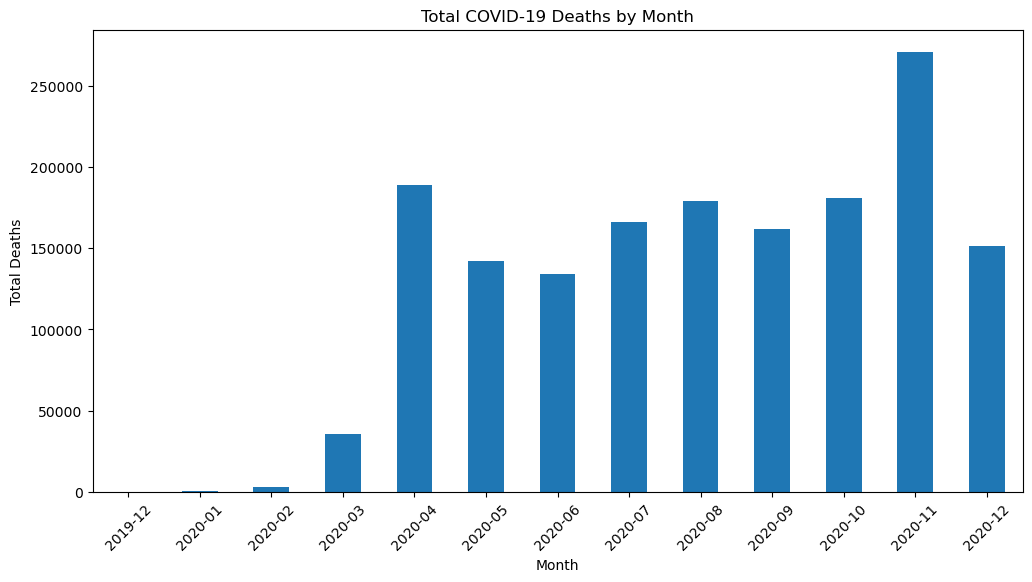

In [88]:
# رسم إجمالي الوفيات حسب الشهر
monthly_data["deaths"].plot(
    kind="bar",
    figsize=(12, 6),
    title="Total COVID-19 Deaths by Month"
)

plt.xlabel("Month")
plt.ylabel("Total Deaths")
plt.xticks(rotation=45)
plt.show()

In [90]:
# المرحلة 9: مقارنة الدول المهمة 13: اختر دولتين للمقارنة، مثل: إيطاليا والصين ثم اعرض الإصابات والوفيات لكل شهر لكل دولة.

# تحويل التاريخ إلى صيغة تاريخ
ddf["dateRep"] = pd.to_datetime(ddf["dateRep"], dayfirst=True)

# استخراج الشهر
df["Month"] = ddf["dateRep"].dt.to_period("M")

# اختيار إيطاليا والصين
selected_countries = df[df["Countries"].isin(["Italy", "China"])]

# حساب إجمالي الإصابات والوفيات لكل شهر لكل دولة
comparison = selected_countries.groupby(
    ["Month", "Countries"]
)[["cases", "deaths"]].sum()

# عرض النتائج
print(comparison)

                    cases  deaths
Month   Countries                
2019-12 China          27       0
        Italy           0       0
2020-01 China        9687     213
        Italy           3       0
2020-02 China       69641    2624
        Italy         885      21
2020-03 China        2886     472
        Italy      100851   11570
2020-04 China        1703    1328
        Italy      101852   16091
2020-05 China         184       1
        Italy       29073    5658
2020-06 China         652       3
        Italy        7920    1435
2020-07 China        2709      18
        Italy        6722     388
2020-08 China        2406      63
        Italy       21060     345
2020-09 China         633      17
        Italy       44793     398
2020-10 China         771       0
        Italy      334663    2446
2020-11 China         515       0
        Italy      937504   16583
2020-12 China         207       0
        Italy      258534    9616


In [ ]:
# لمرحلة 10: Visualization 


# أعلى 5 دول من حيث إجمالي الوفيات


# حساب إجمالي الوفيات لكل دولة
total_deaths = df.groupby("Countries")["deaths"].sum()

# اختيار أعلى 5 دول
top_5_deaths = total_deaths.sort_values(ascending=False).head(5)

# رسم أعلى 5 دول من حيث إجمالي الوفيات
top_5_deaths.plot(
    kind="bar",
    figsize=(10, 6),
    title="Top 5 Countries by Total Deaths"
)

plt.xlabel("Country")
plt.ylabel("Total Deaths")
plt.xticks(rotation=45)
plt.show()